In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
sc.set_figure_params(dpi=100)
warnings.filterwarnings("ignore")
sc.set_figure_params(frameon=False)
import cellhint
import seaborn as sns
pd.set_option('display.max_columns', None)


In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay

# Load

In [10]:
adata = sc.read_h5ad('../data/single_cell/05112024_concatenate_sc_scpoli_int.h5ad')

In [5]:
sc.pp.filter_genes(adata, min_cells=10)

In [6]:
adata

AnnData object with n_obs × n_vars = 433597 × 37323
    obs: 'CellTypes', 'Dataset', 'ID', 'alternative_qc_status', 'annotation_l1_espace', 'annotation_l2_espace', 'annotation_l3_espace', 'annotation_l4_espace', 'cell_passed_qc', 'espace_id', 'log1p_n_counts', 'log1p_n_genes', 'n_counts', 'n_counts_hb', 'n_counts_mito', 'n_counts_ribo', 'n_genes', 'passed_qc', 'percent_hb', 'percent_mito', 'percent_ribo', 'percent_top50', 'qc_status', 'user_qc_status', 'Cell Type', 'Cell Type Grouped', 'Chemistry', 'Diabetes Status', 'Library', 'Percent MT', 'Seurat Clusters', 'Sex', 'Tissue Source', 'nCount_RNA', 'nFeature_RNA', 'BMI', 'HbA1c', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'ethnicity_ontology_term_id', 'glucose_SI', 'insulin_content', 'is_primary_data', 'louvain_anno_broad', 'louvain_anno_fine', 'mt_frac', 'organism_ontolology_term_id', 'sample', 'sex_ontology_term_id', 'size_factors', 'tissue_ontology_term_id

In [112]:
# espace l3 is equivalent to other datasets

In [4]:
adata.obs = adata.obs.astype(str)

In [5]:
adata.obs.loc[adata.obs['Dataset'] == 'espace_scRNA_cultured_islets', 'CellTypes'] = adata.obs.loc[adata.obs['Dataset'] == 'espace_scRNA_cultured_islets', 'annotation_l3_espace']

# Resolve Discrepancy by label harmonization per dataset

In [6]:
adata_label = adata[adata.obs.Dataset.isin(['GSE183568', 'GSE198623', 'HPAP', 'espace_scRNA_cultured_islets'])]

In [7]:
adata_label

View of AnnData object with n_obs × n_vars = 325374 × 37323
    obs: 'CellTypes', 'Dataset', 'ID', 'alternative_qc_status', 'annotation_l1_espace', 'annotation_l2_espace', 'annotation_l3_espace', 'annotation_l4_espace', 'cell_passed_qc', 'espace_id', 'log1p_n_counts', 'log1p_n_genes', 'n_counts', 'n_counts_hb', 'n_counts_mito', 'n_counts_ribo', 'n_genes', 'passed_qc', 'percent_hb', 'percent_mito', 'percent_ribo', 'percent_top50', 'qc_status', 'user_qc_status', 'Cell Type', 'Cell Type Grouped', 'Chemistry', 'Diabetes Status', 'Library', 'Percent MT', 'Seurat Clusters', 'Sex', 'Tissue Source', 'nCount_RNA', 'nFeature_RNA', 'BMI', 'HbA1c', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'ethnicity_ontology_term_id', 'glucose_SI', 'insulin_content', 'is_primary_data', 'louvain_anno_broad', 'louvain_anno_fine', 'mt_frac', 'organism_ontolology_term_id', 'sample', 'sex_ontology_term_id', 'size_factors', 'tissue_ontology

In [8]:
df_celltypes = adata_label.obs.groupby('Dataset')['CellTypes'].apply(lambda x: pd.Series(x.unique())).unstack().reset_index()

In [9]:
df_celltypes

,Dataset,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,GSE183568,Endothelial,Beta,Acinar,Alpha,Stellate,Delta,Ductal,Immune,Gamma,Epsilon,FACS-Beta,FACS-Alpha,NaN,NaN
1,GSE198623,alpha_stress II,delta,alpha_mature,beta_mature,alpha_immature,beta_immature,beta_stress II,beta_stress I,beta_MHC/autoantigen,alpha_MHC II,beta_mtDNA deficient,PP,NaN,NaN
2,HPAP,Beta,Mast,Ductal,Active Stellate,Macrophage,Alpha,Gamma+Epsilon,Alpha+Beta,Delta,Endothelial,Cycling Alpha,Quiescent Stellate,Acinar,MUC5B+ Ductal
3,espace_scRNA_cultured_islets,Endothelial,Acinar,Ductal,Alpha,Beta,PP,Delta,Epsilon,T,Macrophages,Cycling_T,Schwann,Stellate,NaN


In [10]:
adata_label.obs.Level_1_manual.unique().tolist()

['Endothelial Cell',
 'Ductal Cell',
 'Acinar Cell',
 'T Cell',
 'Pericyte',
 'Quiescent Stellate Cell',
 'Beta Cell',
 'Alpha Cell',
 'Progenitor Endocrine Cell',
 'Epsilon Cell',
 'Delta Cell',
 'Pancreatic Polypeptide Cell',
 'Macrophage',
 'Neutrophil',
 'Activated Stellate Cell',
 'Proliferating Endocrine Cell']

In [11]:
adata_label.obs.CellTypes.unique().tolist()

['Endothelial',
 'Acinar',
 'Ductal',
 'Alpha',
 'Beta',
 'PP',
 'Delta',
 'Epsilon',
 'T',
 'Macrophages',
 'Cycling_T',
 'Schwann',
 'Stellate',
 'Mast',
 'Active Stellate',
 'Macrophage',
 'Gamma+Epsilon',
 'Alpha+Beta',
 'Cycling Alpha',
 'Quiescent Stellate',
 'MUC5B+ Ductal',
 'alpha_stress II',
 'delta',
 'alpha_mature',
 'beta_mature',
 'alpha_immature',
 'beta_immature',
 'beta_stress II',
 'beta_stress I',
 'beta_MHC/autoantigen',
 'alpha_MHC II',
 'beta_mtDNA deficient',
 'Immune',
 'Gamma',
 'FACS-Beta',
 'FACS-Alpha']

In [12]:
mapping_dict = {
    'Endothelial': 'Endothelial Cell',
    'Acinar': 'Acinar Cell',
    'Ductal': 'Ductal Cell',
    'Alpha': 'Alpha Cell',
    'Beta': 'Beta Cell',
    'PP': 'Pancreatic Polypeptide Cell',
    'Delta': 'Delta Cell',
    'Epsilon': 'Epsilon Cell',
    'T': 'T Cell',
    'Macrophages': 'Macrophage',
    'Cycling_T': 'T Cell',  # Closest match
    'Schwann': 'Schwann Cell',  # Nearest stromal cell type
    'Stellate': 'Quiescent Stellate Cell',
    'Mast': 'Mast Cell',  # Closest immune cell
    'Active Stellate': 'Activated Stellate Cell',
    'Macrophage': 'Macrophage',
    'Gamma+Epsilon': 'Pancreatic Polypeptide + Epsilon Cell',  # Closest match
    'Alpha+Beta': 'Alpha + Beta Cell',  # Simplified
    'Cycling Alpha': 'Alpha Cell',
    'Quiescent Stellate': 'Quiescent Stellate Cell',
    'MUC5B+ Ductal': 'Ductal Cell',
    'alpha_stress II': 'Alpha Cell',  # Simplified to Alpha Cell
    'delta': 'Delta Cell',
    'alpha_mature': 'Alpha Cell',
    'beta_mature': 'Beta Cell',
    'alpha_immature': 'Alpha Cell',
    'beta_immature': 'Beta Cell',
    'beta_stress II': 'Beta Cell',
    'beta_stress I': 'Beta Cell',
    'beta_MHC/autoantigen': 'Beta Cell',
    'alpha_MHC II': 'Alpha Cell',
    'beta_mtDNA deficient': 'Beta Cell',
    'Immune': 'T Cell',  # General immune category
    'Gamma': 'Pancreatic Polypeptide Cell',  # Closest match
    'FACS-Beta': 'Beta Cell',
    'FACS-Alpha': 'Alpha Cell'
}

In [13]:
adata_label.obs['CellTypes_Harmonized_Manual'] = adata_label.obs.CellTypes.map(mapping_dict)

... storing 'CellTypes' as categorical
... storing 'CellTypes_Harmonized_Manual' as categorical


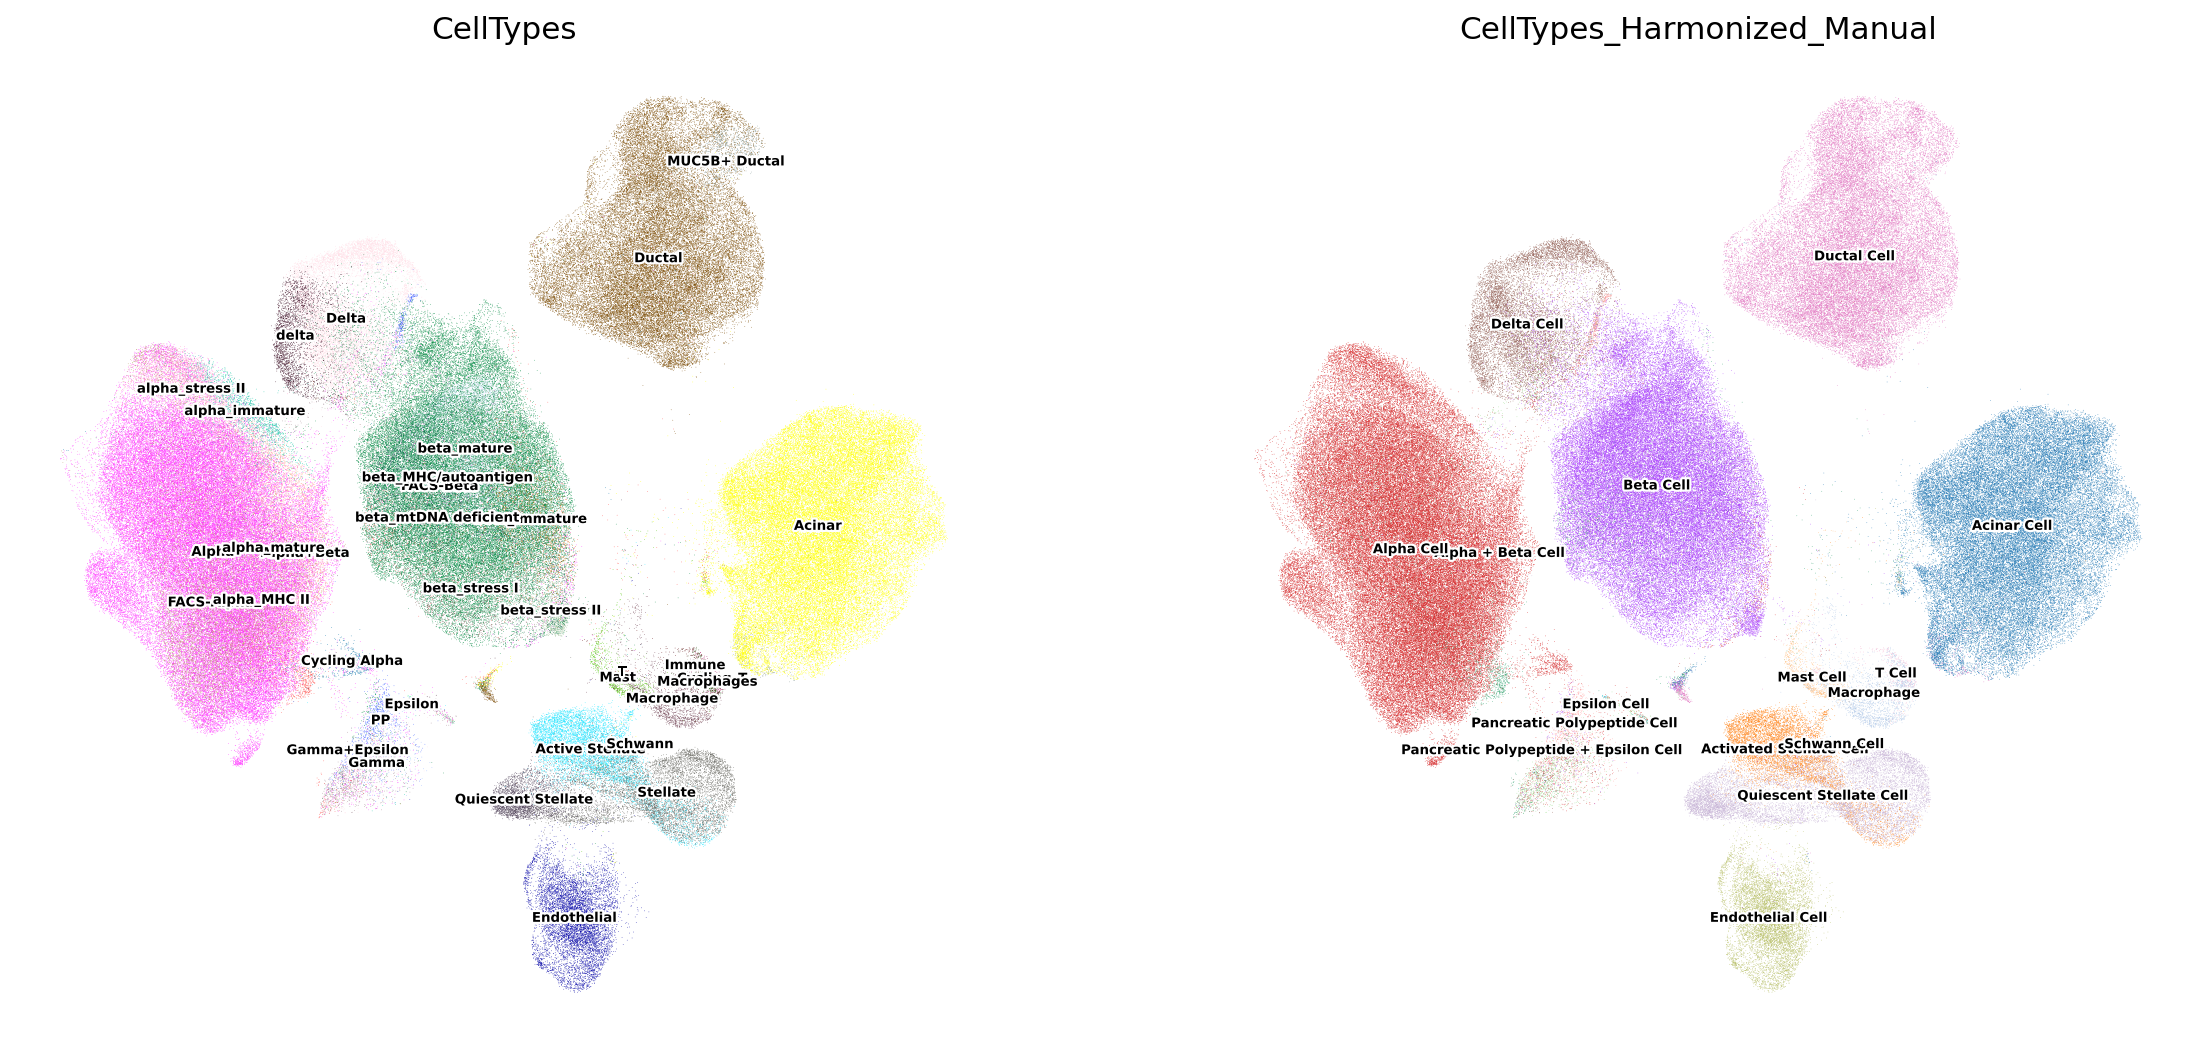

In [136]:
sc.pl.umap(adata_label, color=['CellTypes', 'CellTypes_Harmonized_Manual'], ncols=2, legend_fontsize=6, legend_loc='on data', legend_fontoutline=2)

# Bring All Datasets Harmonized to Level 1 equivalent

In [14]:
[i for i in adata_label.obs.CellTypes_Harmonized_Manual.unique().tolist() if i not in adata_label.obs.Level_1_manual.unique().tolist()]

['Schwann Cell',
 'Mast Cell',
 'Pancreatic Polypeptide + Epsilon Cell',
 'Alpha + Beta Cell']

In [138]:
df_celltypes = adata_label.obs.groupby('Dataset')['CellTypes_Harmonized_Manual'].apply(lambda x: pd.Series(x.unique())).unstack().reset_index()

In [139]:
df_celltypes

,Dataset,0,1,2,3,4,5,6,7,8,9,10,11
0,GSE183568,Endothelial Cell,Beta Cell,Acinar Cell,Alpha Cell,Quiescent Stellate Cell,Delta Cell,Ductal Cell,T Cell,Pancreatic Polypeptide Cell,Epsilon Cell,NaN,NaN
1,GSE198623,Alpha Cell,Delta Cell,Beta Cell,Pancreatic Polypeptide Cell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HPAP,Beta Cell,Mast Cell,Ductal Cell,Activated Stellate Cell,Macrophage,Alpha Cell,Pancreatic Polypeptide + Epsilon Cell,Alpha + Beta Cell,Delta Cell,Endothelial Cell,Quiescent Stellate Cell,Acinar Cell
3,espace_scRNA_cultured_islets,Endothelial Cell,Acinar Cell,Ductal Cell,Alpha Cell,Beta Cell,Pancreatic Polypeptide Cell,Delta Cell,Epsilon Cell,T Cell,Macrophage,Schwann Cell,Quiescent Stellate Cell


In [140]:
sc.tl.rank_genes_groups(adata_label, groupby='CellTypes_Harmonized_Manual', layer='normcounts')

In [143]:
pd.DataFrame(adata_label.uns['rank_genes_groups']['names']).head(50)[['Pancreatic Polypeptide + Epsilon Cell', 'Alpha + Beta Cell']]

,Pancreatic Polypeptide + Epsilon Cell,Alpha + Beta Cell
0,PCSK1N,ATP5F1E
1,SCG5,PCSK1N
2,CHGB,TTR
3,CPE,SNHG29
4,IDS,RNASEK
5,CLU,EEF1G
6,BEX1,BEX1
7,FXYD2,GNAS
8,PTPRN,MIF
9,CIRBP,ATP5MG


In [15]:
fine_mapping = {'Pancreatic Polypeptide + Epsilon Cell': 'Pancreatic Polypeptide Cell', 'Alpha + Beta Cell': 'Ambiguous Cell'}

In [16]:
adata_label.obs['CellTypes_Harmonized_Manual'] = (adata_label.obs['CellTypes_Harmonized_Manual'].map(fine_mapping).fillna(adata_label.obs['CellTypes_Harmonized_Manual']))

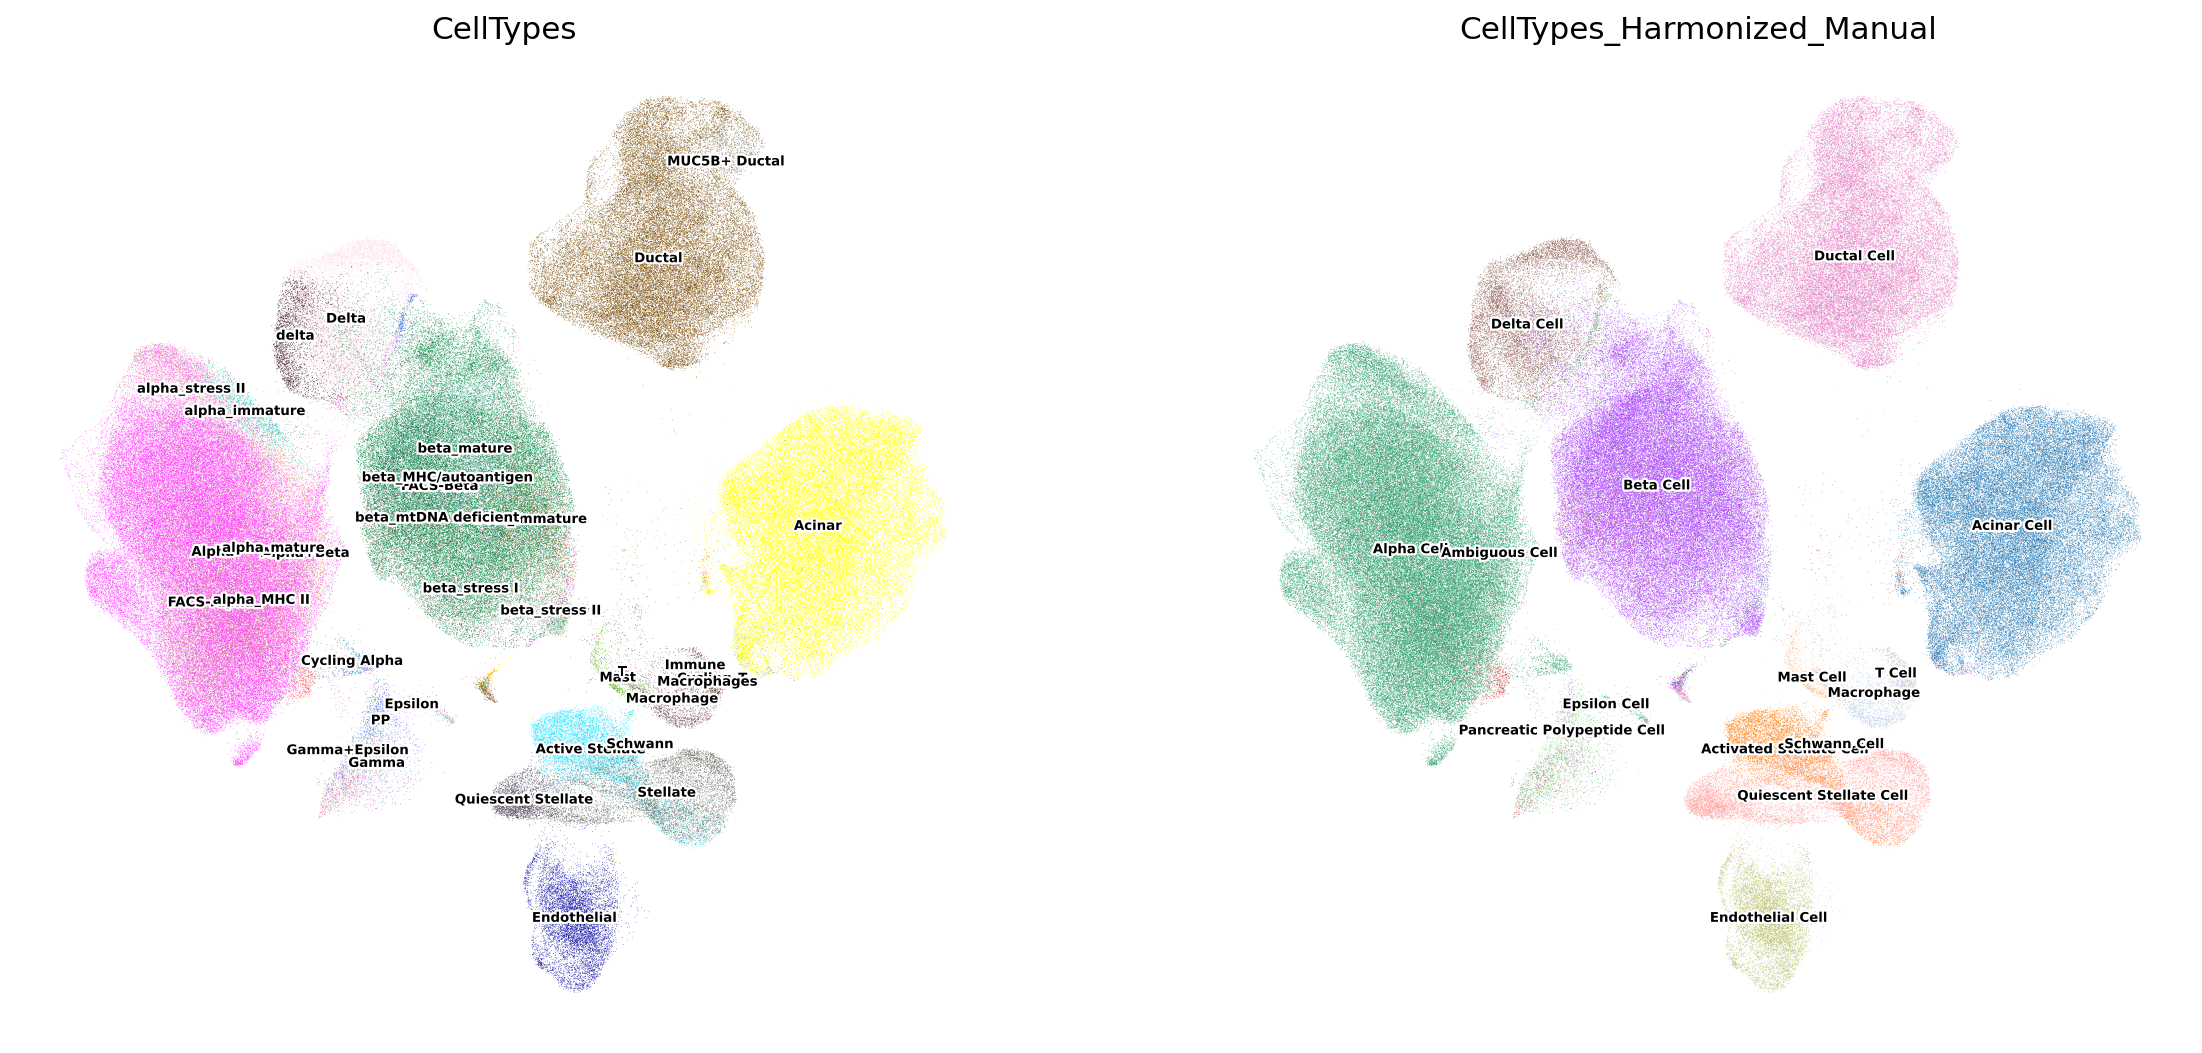

In [18]:
plt.rcParams['figure.figsize'] = (8, 8)
sc.pl.umap(adata_label, color=['CellTypes', 'CellTypes_Harmonized_Manual'], ncols=2, legend_fontsize=6, legend_loc='on data', legend_fontoutline=2)

In [402]:
adata_label.var_names[adata_label.var_names.isin(['PDX1', 'SOX9'])]

Index(['PDX1', 'SOX9'], dtype='object')

In [165]:
adata_label.var_names[adata_label.var_names.isin(['PAPPA2', 'PLIN2'])]

Index(['PAPPA2', 'PLIN2'], dtype='object')

In [188]:
adata_label.var_names[adata_label.var_names.str.contains('CD4')]

Index(['ABCD4', 'C2CD4A', 'C2CD4B', 'C2CD4C', 'C2CD4D', 'C2CD4D-AS1', 'CD4',
       'CD40', 'CD40LG', 'CD44', 'CD44-AS1', 'CD44-DT', 'CD46', 'CD47', 'CD48',
       'HACD4', 'PDCD4', 'PDCD4-AS1', 'PLCD4', 'TLCD4'],
      dtype='object')

In [34]:
filtered_dict_final = {
    'Acinar Cell': ['CPA1', 'PRSS1'],
    'Alpha Cell': ['GCG', 'PAPPA2'],
    'Beta Cell': ['MAFA', 'INS'],
    'Delta Cell': ['SST', 'HHEX'],
    'Ductal Cell': ['KRT19', 'ANXA4'],
    'Endothelial Cell': ['PECAM1', 'VWF'],
    'Macrophage': ['CD68', 'MSR1'],
    'Mast Cell': ['TPSAB1', 'TPSD1'],
    'Activated Stellate Cell': ['PDGFRB', 'COL1A1'],
    'Quiescent Stellate Cell': ['CYGB', 'PLIN2'],
    'Pancreatic Polypeptide Cell': ['PPY', 'CHGA'],
    'Schwann Cell': ['GAP43', 'S100B'],
    'Progenitor Endocrine Cell': ['PAX6', 'SOX9'],
    'Epsilon Cell': ['GHRL', 'PDX1'],
    'T Cell': ['CD3D', 'CD4']
}

In [20]:
desired_order = adata_label.obs['CellTypes_Harmonized_Manual'].unique()
reordered_dict = {key: filtered_dict_final[key] for key in desired_order if key in filtered_dict_final}

In [21]:
category_order = [i for i in adata_label.obs['CellTypes_Harmonized_Manual'].cat.categories.tolist() if i in filtered_dict_final]
reordered_dict = {key: filtered_dict_final[key] for key in category_order}

In [22]:
reordered_dict

{'Acinar Cell': ['CPA1', 'PRSS1'],
 'Activated Stellate Cell': ['PDGFRB', 'COL1A1'],
 'Alpha Cell': ['GCG', 'PAPPA2'],
 'Beta Cell': ['MAFA', 'INS'],
 'Delta Cell': ['SST', 'HHEX'],
 'Ductal Cell': ['KRT19', 'ANXA4'],
 'Endothelial Cell': ['PECAM1', 'VWF'],
 'Epsilon Cell': ['GHRL', 'PDX1'],
 'Macrophage': ['CD68', 'MSR1'],
 'Mast Cell': ['TPSAB1', 'TPSD1'],
 'Pancreatic Polypeptide Cell': ['PPY', 'CHGA'],
 'Quiescent Stellate Cell': ['CYGB', 'PLIN2'],
 'Schwann Cell': ['GAP43', 'S100B'],
 'T Cell': ['CD3D', 'CD4']}

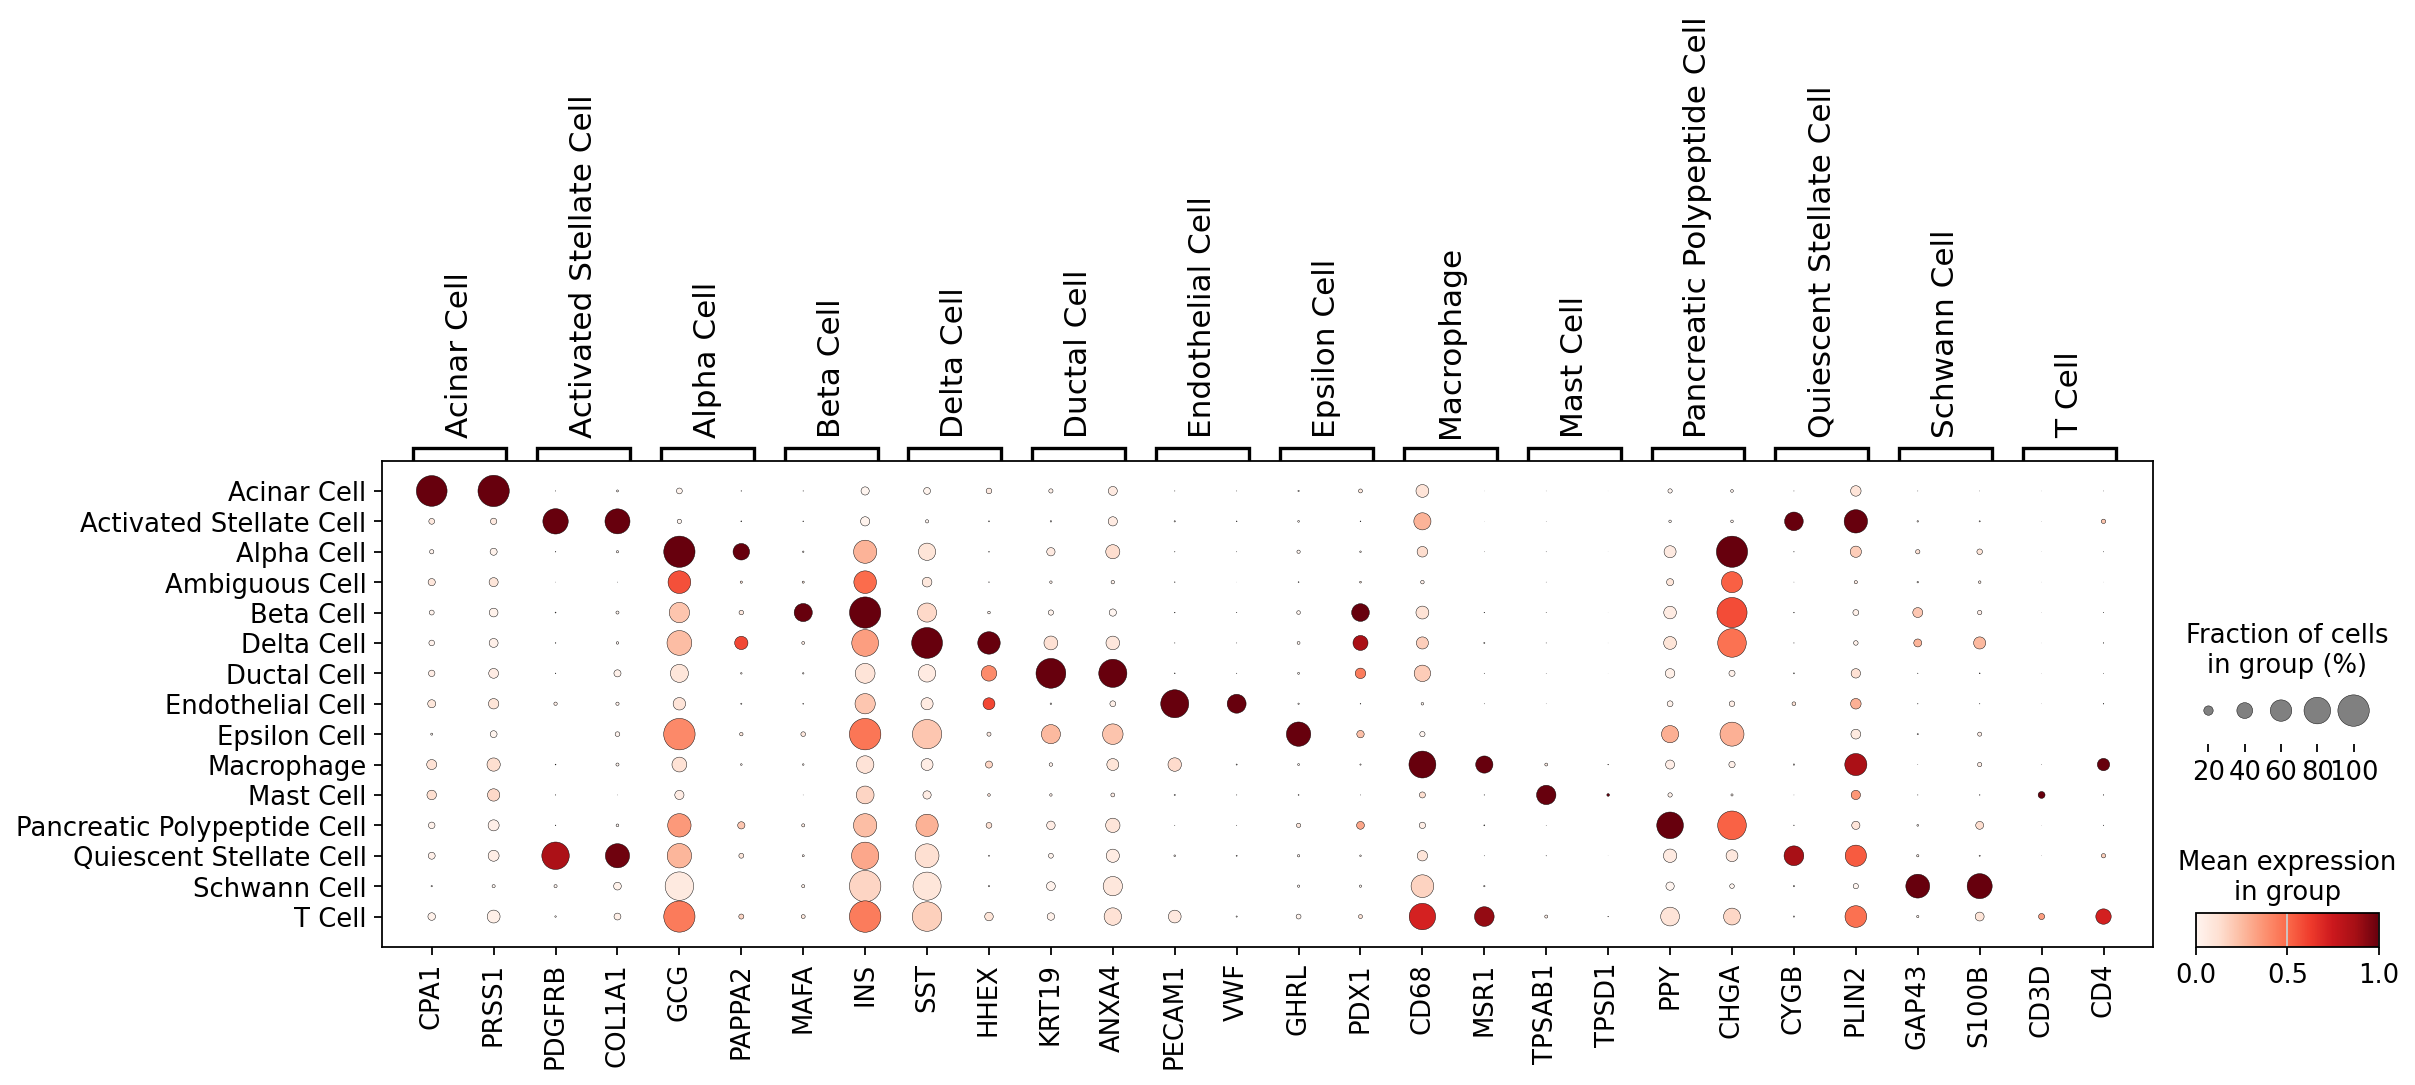

In [23]:
sc.pl.dotplot(adata_label, reordered_dict, groupby='CellTypes_Harmonized_Manual', figsize=(16, 4), layer='normcounts', standard_scale='var', swap_axes=False)

espace_scRNA_cultured_islets


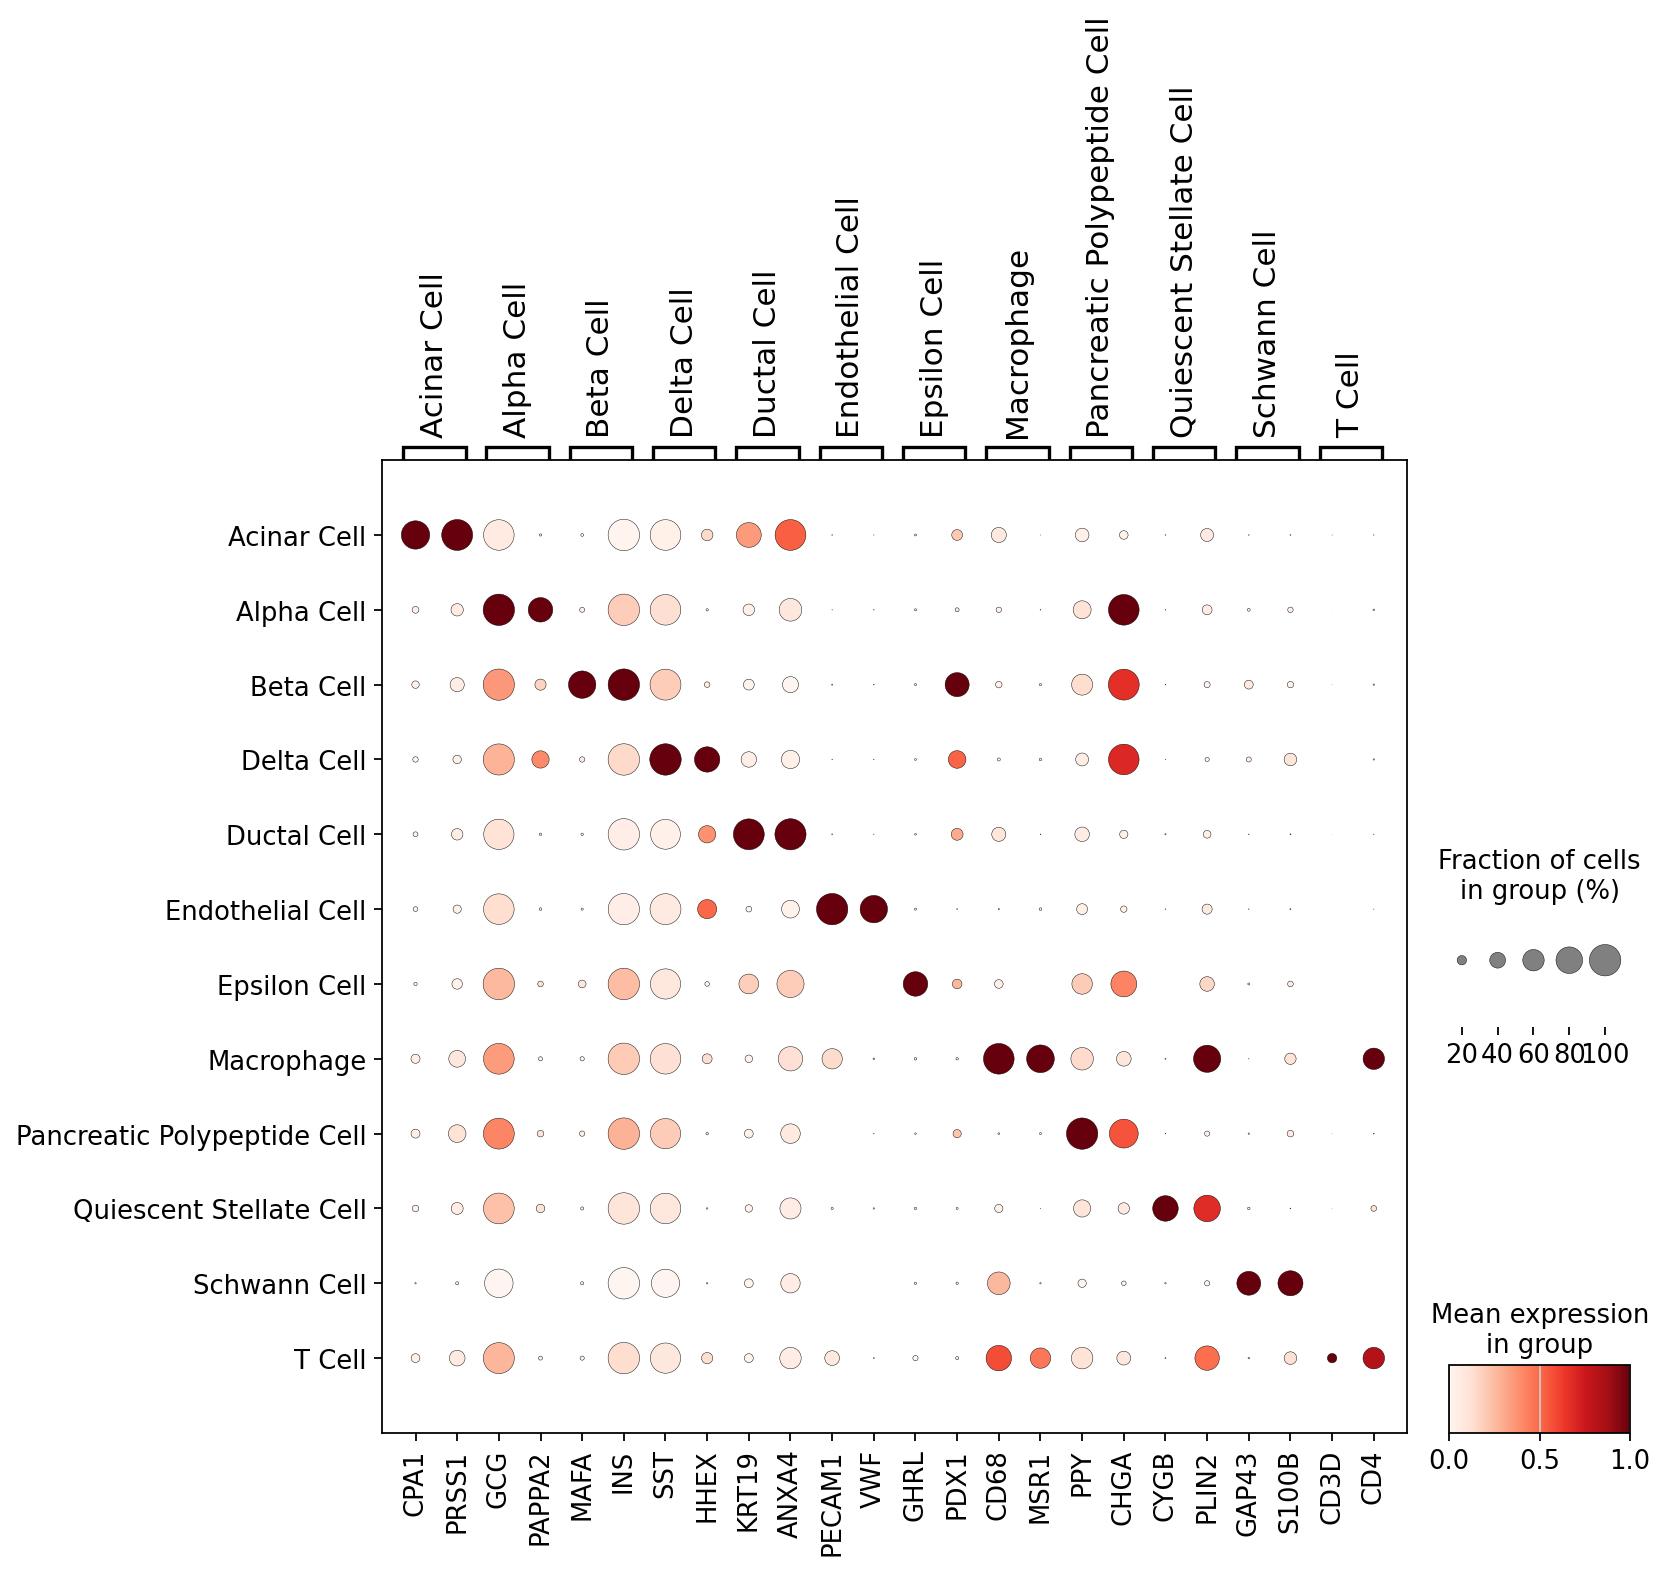

HPAP


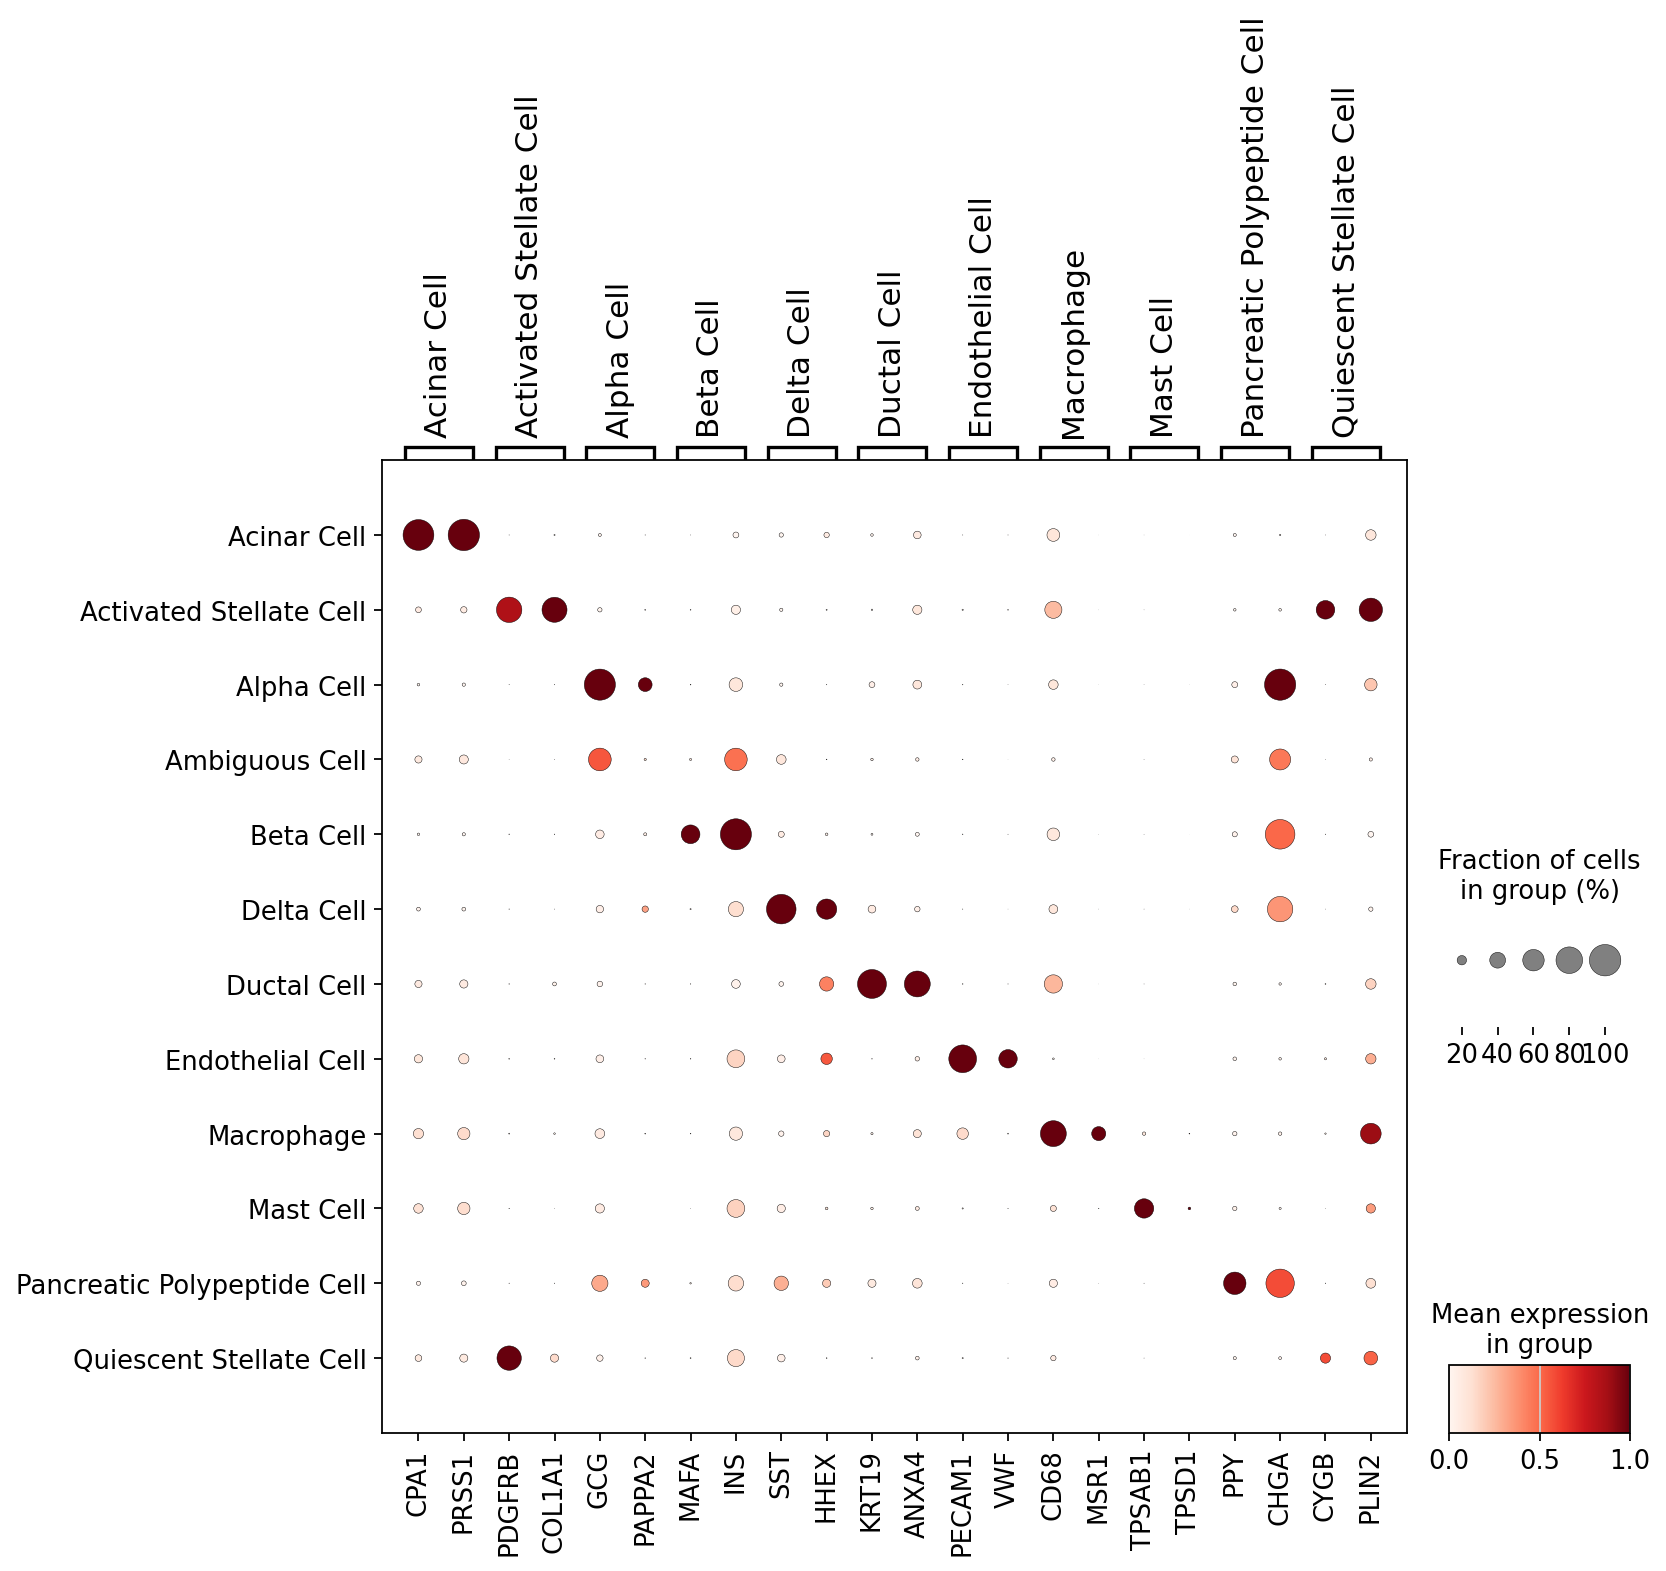

GSE198623


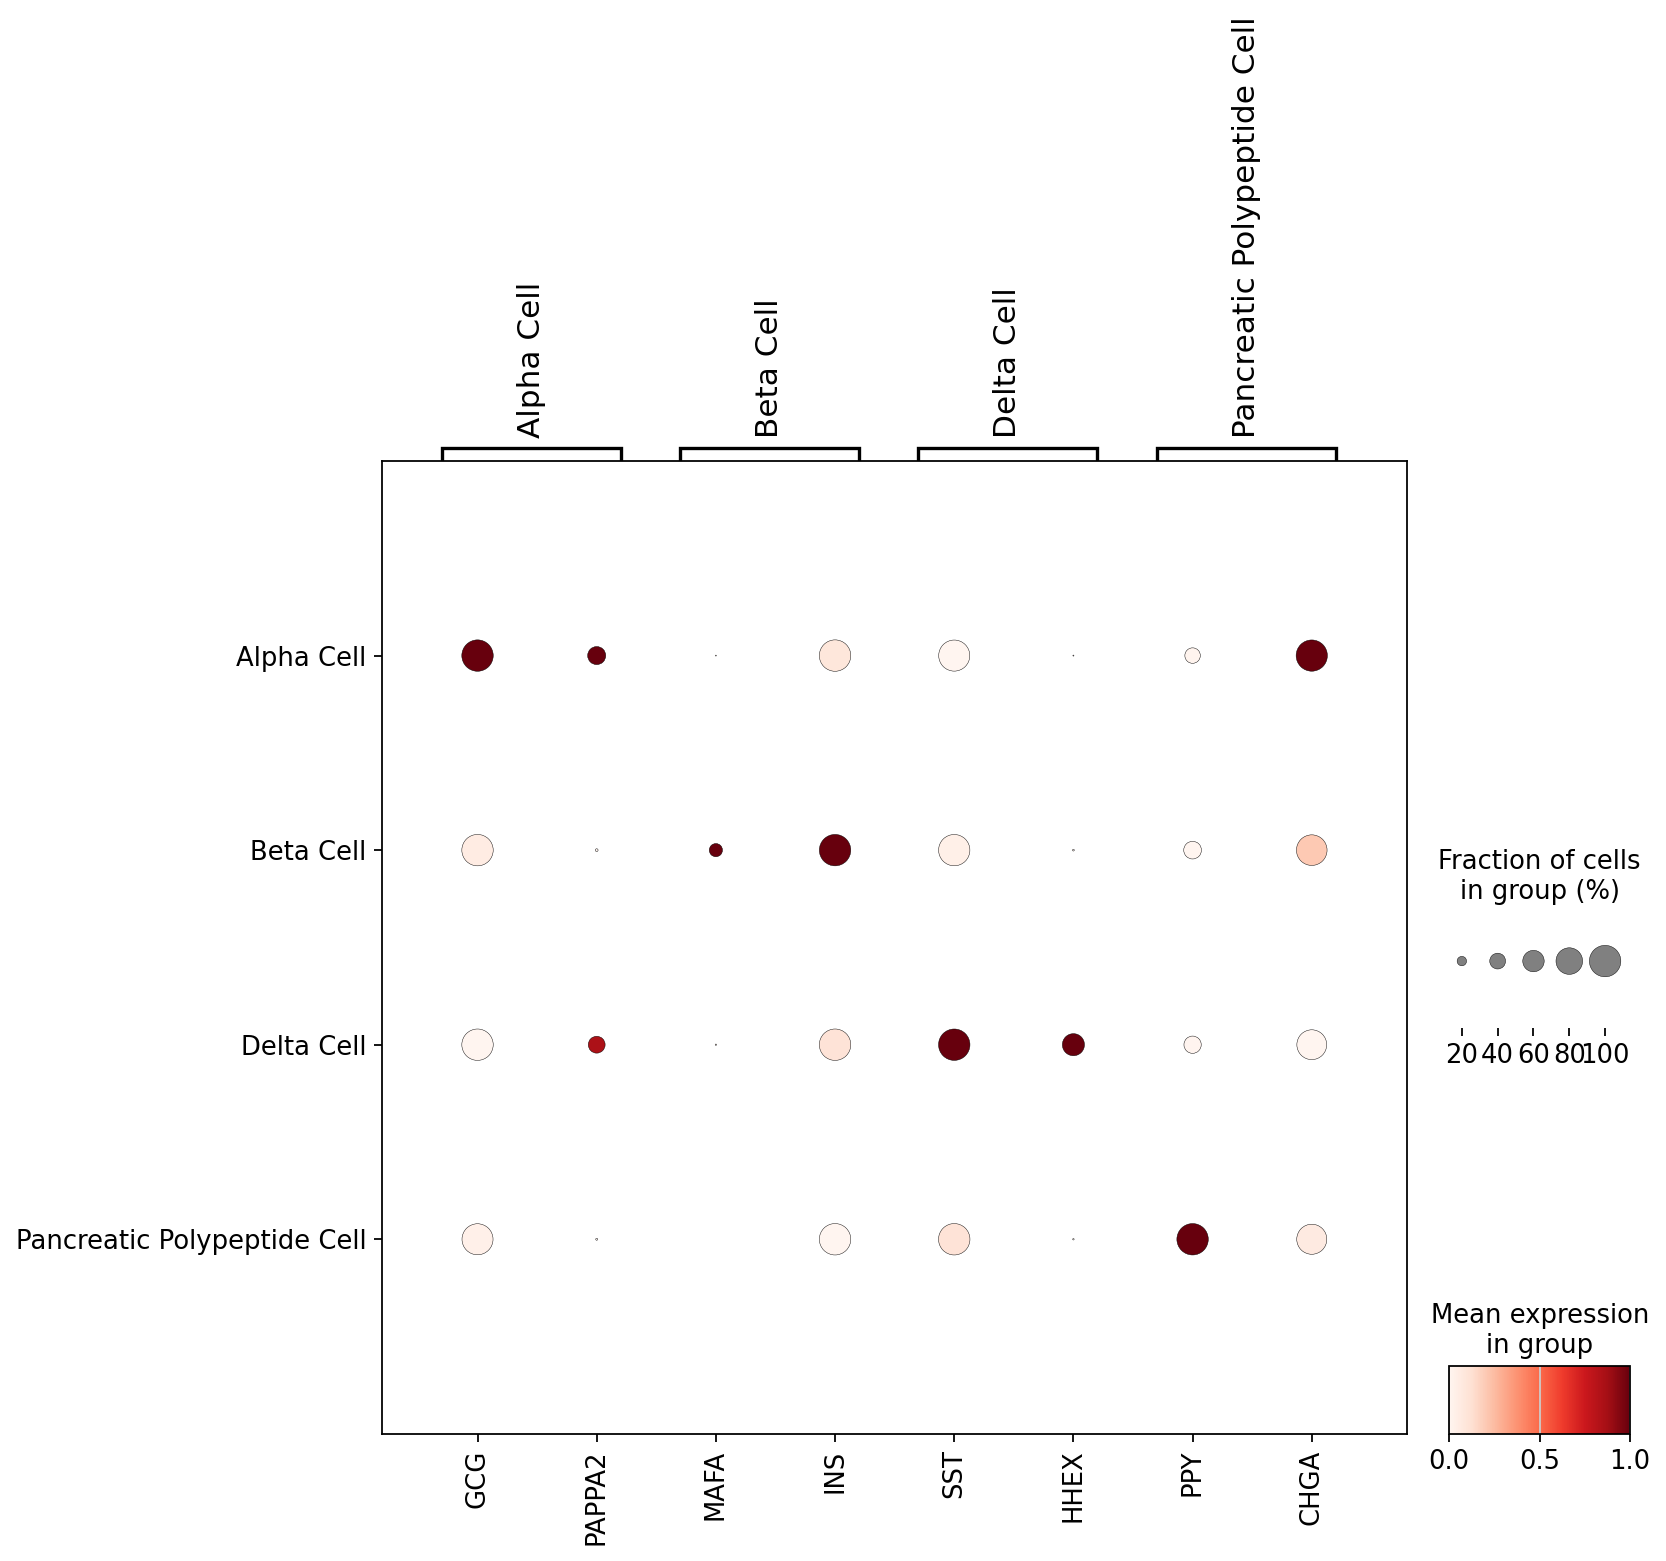

GSE183568


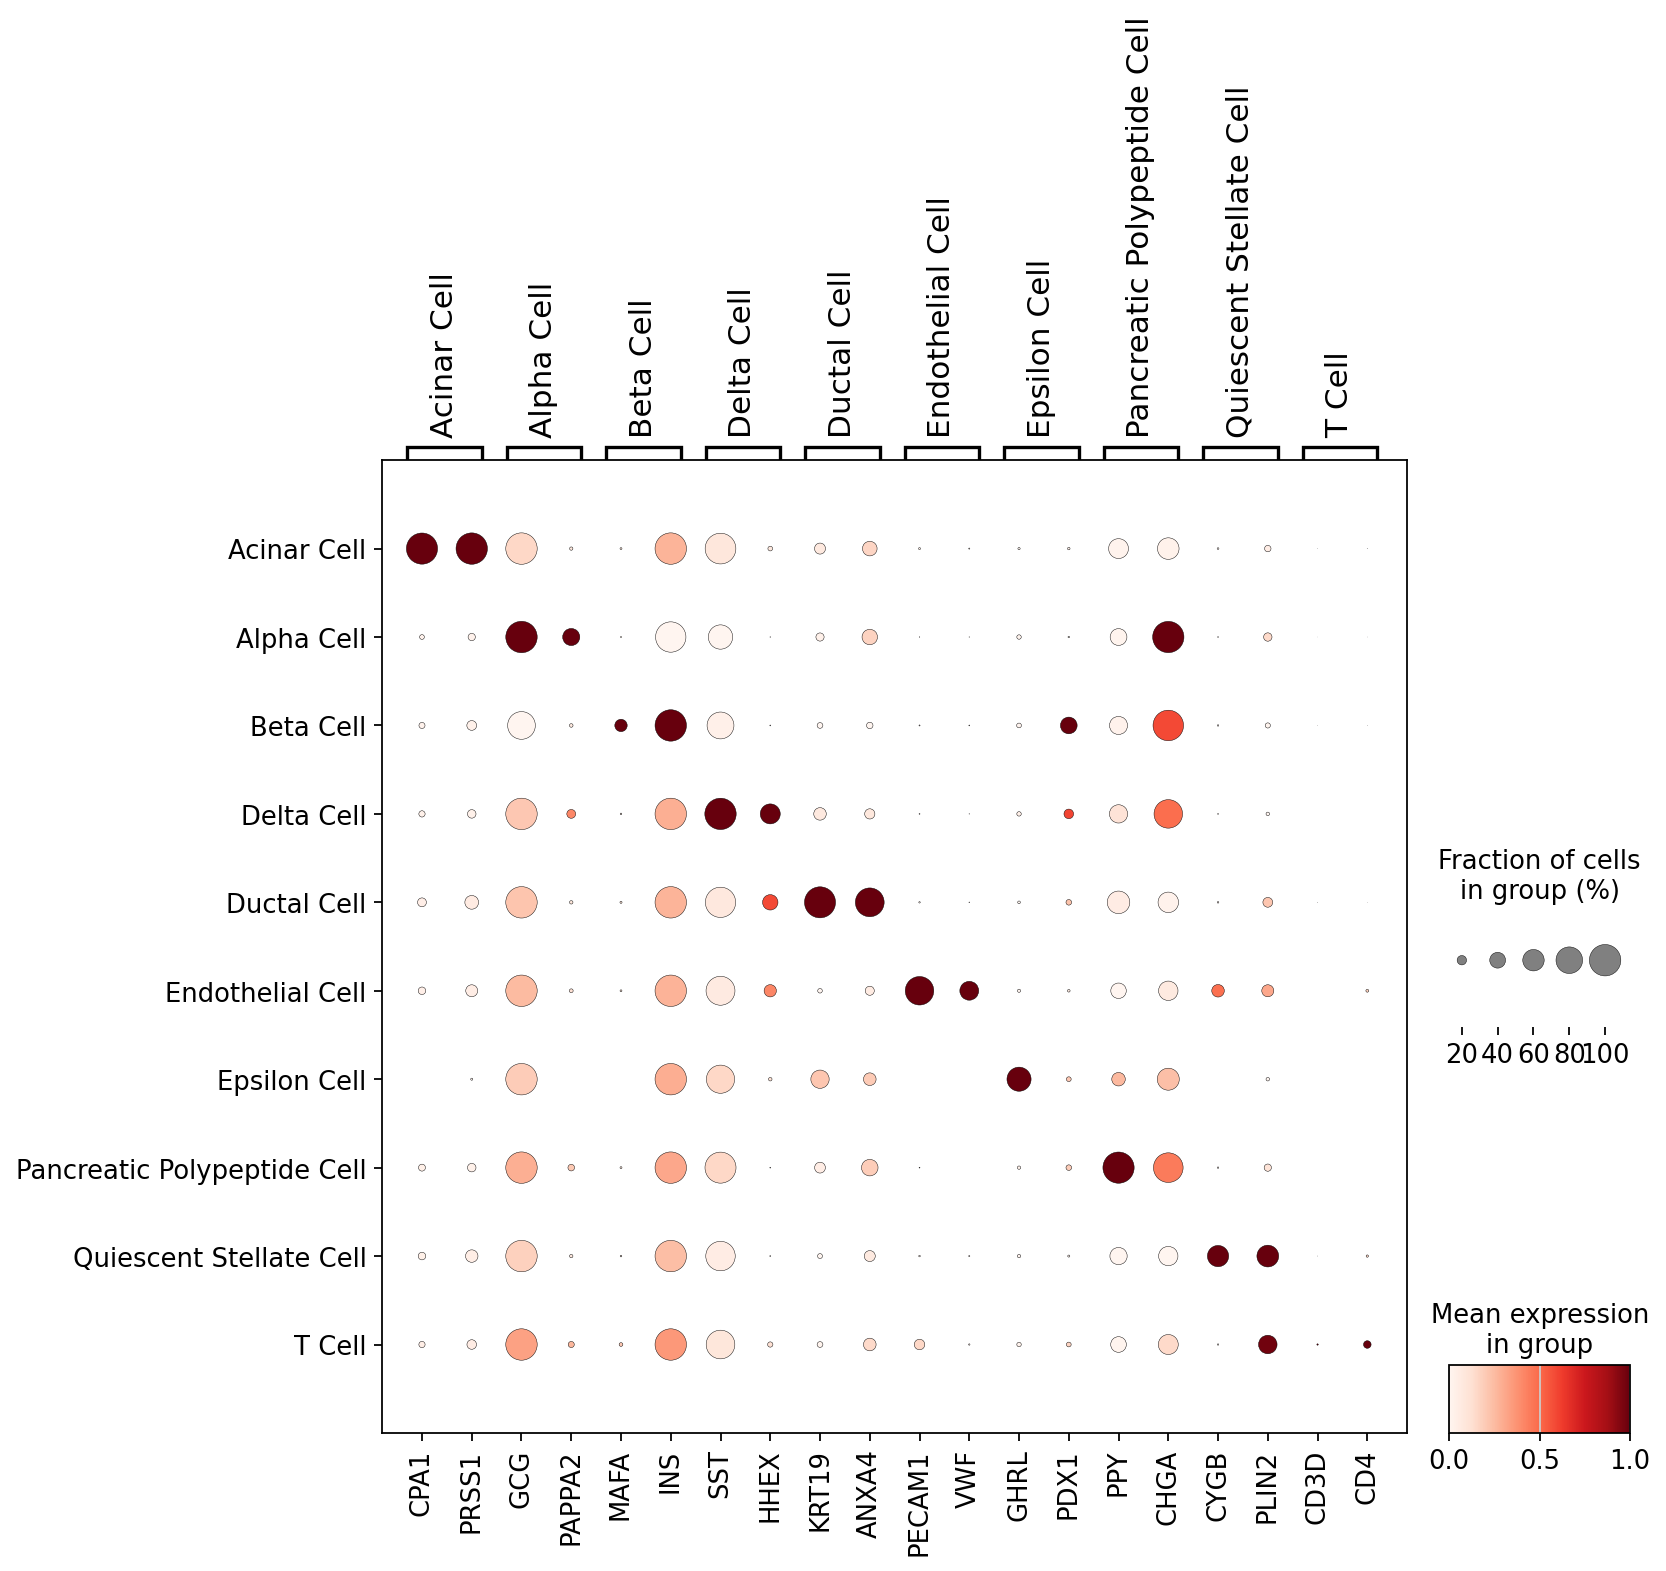

In [194]:
for dataset in adata_label.obs.Dataset.unique().tolist():
    adata_temp = adata_label[adata_label.obs.Dataset == dataset]
    present_cell_types = adata_temp.obs['CellTypes_Harmonized_Manual'].unique()
    plot_dict = {k: reordered_dict[k] for k in present_cell_types if k in reordered_dict}
    category_order = [i for i in adata_temp.obs['CellTypes_Harmonized_Manual'].cat.categories.tolist() if i in plot_dict]
    plot_dict = {key: plot_dict[key] for key in category_order}
    print(dataset)
    sc.pl.dotplot(adata_temp, plot_dict, groupby='CellTypes_Harmonized_Manual', figsize=(10, 8), layer='normcounts', standard_scale='var', swap_axes=False)

# Check representation of adata_label with metadata

In [203]:
adata_label.obs.columns

Index(['CellTypes', 'Dataset', 'ID', 'alternative_qc_status',
       'annotation_l1_espace', 'annotation_l2_espace', 'annotation_l3_espace',
       'annotation_l4_espace', 'cell_passed_qc', 'espace_id', 'log1p_n_counts',
       'log1p_n_genes', 'n_counts', 'n_counts_hb', 'n_counts_mito',
       'n_counts_ribo', 'n_genes', 'passed_qc', 'percent_hb', 'percent_mito',
       'percent_ribo', 'percent_top50', 'qc_status', 'user_qc_status',
       'Cell Type', 'Cell Type Grouped', 'Chemistry', 'Diabetes Status',
       'Library', 'Percent MT', 'Seurat Clusters', 'Sex', 'Tissue Source',
       'nCount_RNA', 'nFeature_RNA', 'BMI', 'HbA1c', 'assay_ontology_term_id',
       'cell_type_ontology_term_id', 'development_stage_ontology_term_id',
       'disease_ontology_term_id', 'ethnicity_ontology_term_id', 'glucose_SI',
       'insulin_content', 'is_primary_data', 'louvain_anno_broad',
       'louvain_anno_fine', 'mt_frac', 'organism_ontolology_term_id', 'sample',
       'sex_ontology_term_id', 'si

In [199]:
adata_label.obs.groupby('Dataset').size()

Dataset
GSE183568                        55275
GSE198623                        26474
HPAP                            192203
espace_scRNA_cultured_islets     51422
dtype: int64

In [24]:
adata_label.write('../data/single_cell/04122024_adata_labelled.h5ad')